In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Bengkod /Ujian Akhir Semester/Sales - Marketing customer dataset.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [ ]:
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [ ]:
df.tail()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
14995,24996,Female,24.0,UK,New York,2023-10-23 00:00:00,2024-03-02 00:00:00,Referral,Desktop,Monthly,...,3,0,3,UPI,4.0,2,16.96,796.486833,9,0
14996,24997,Male,26.0,Bangladesh,London,2023-01-20 00:00:00,2024-12-03 00:00:00,Google Ads,Mobile,Monthly,...,3,0,2,BKash,NaN,6,23.86,2155.987233,0,0
14997,24998,Male,42.0,USA,Dhaka,2022-10-11 00:00:00,2023-12-04 00:00:00,Organic,Desktop,Monthly,...,3,0,5,UPI,4.0,4,12.55,614.326226,14,0
14998,24999,Female,31.0,UK,Dhaka,2022-04-01 00:00:00,2024-11-11 00:00:00,Facebook Ads,Desktop,Monthly,...,5,1,1,UPI,3.0,1,19.03,849.936622,8,1
14999,25000,Male,23.0,Bangladesh,Berlin,2023-09-20 00:00:00,2024-06-04 00:00:00,Google Ads,Tablet,Annual,...,1,0,2,PayPal,4.0,4,25.86,1393.092943,8,0


In [ ]:
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [ ]:
df.isnull().sum()

,0
customer_id,0
gender,738
age,1200
country,0
city,0
signup_date,0
last_purchase_date,0
acquisition_channel,0
device_type,0
subscription_type,0


In [ ]:
missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase Missing (%)': (df.isnull().sum() / len(df)) * 100
})

# Tampilkan hanya kolom yang memiliki missing value
missing = missing[missing['Jumlah Missing'] > 0]

# Urutkan dari missing terbesar
missing = missing.sort_values(by='Persentase Missing (%)', ascending=False)

print(missing)

                    Jumlah Missing  Persentase Missing (%)
coupon_code                   6133               40.886667
age                           1200                8.000000
total_spent                   1050                7.000000
gender                         738                4.920000
satisfaction_score             702                4.680000


In [ ]:
df.duplicated().sum()

np.int64(0)

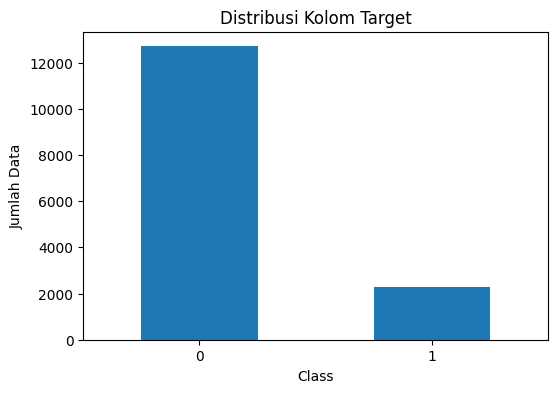

In [ ]:
# Hitung distribusi
target_dist = df['churn'].value_counts()

# Plot
plt.figure(figsize=(6,4))
target_dist.plot(kind='bar')

plt.xlabel('Class')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Kolom Target')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Membuat dataset terpisah untuk masing-masing mekanisme modeling

# 1. Direct Modeling
df_direct = df.copy()

# 2. Pre-processing Modeling
df_prepo = df.copy()

# Melihat ukuran dataset
print(df_direct.shape)
print(df_prepo.shape)

(15000, 30)
(15000, 30)


In [ ]:
# Imputasi data numerik dengan mean
for col in df_direct.select_dtypes(include=['int64', 'float64']).columns:
    df_direct[col] = df_direct[col].fillna(df_direct[col].mean())

# Imputasi data kategorikal dengan modus
for col in df_direct.select_dtypes(include=['object']).columns:
    df_direct[col] = df_direct[col].fillna(df_direct[col].mode()[0])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_direct.select_dtypes(include=['object']).columns:
    df_direct[col] = le.fit_transform(df_direct[col])

# Cek tipe data akhir
print(df_direct.dtypes)

customer_id                     int64
gender                          int64
age                           float64
country                         int64
city                            int64
signup_date                     int64
last_purchase_date              int64
acquisition_channel             int64
device_type                     int64
subscription_type               int64
is_premium_user                 int64
total_visits                    int64
avg_session_time              float64
pages_per_session             float64
email_open_rate               float64
email_click_rate              float64
total_spent                   float64
avg_order_value               float64
discount_used                   int64
coupon_code                     int64
support_tickets                 int64
refund_requested                int64
delivery_delay_days             int64
payment_method                  int64
satisfaction_score            float64
nps_score                       int64
marketing_sp

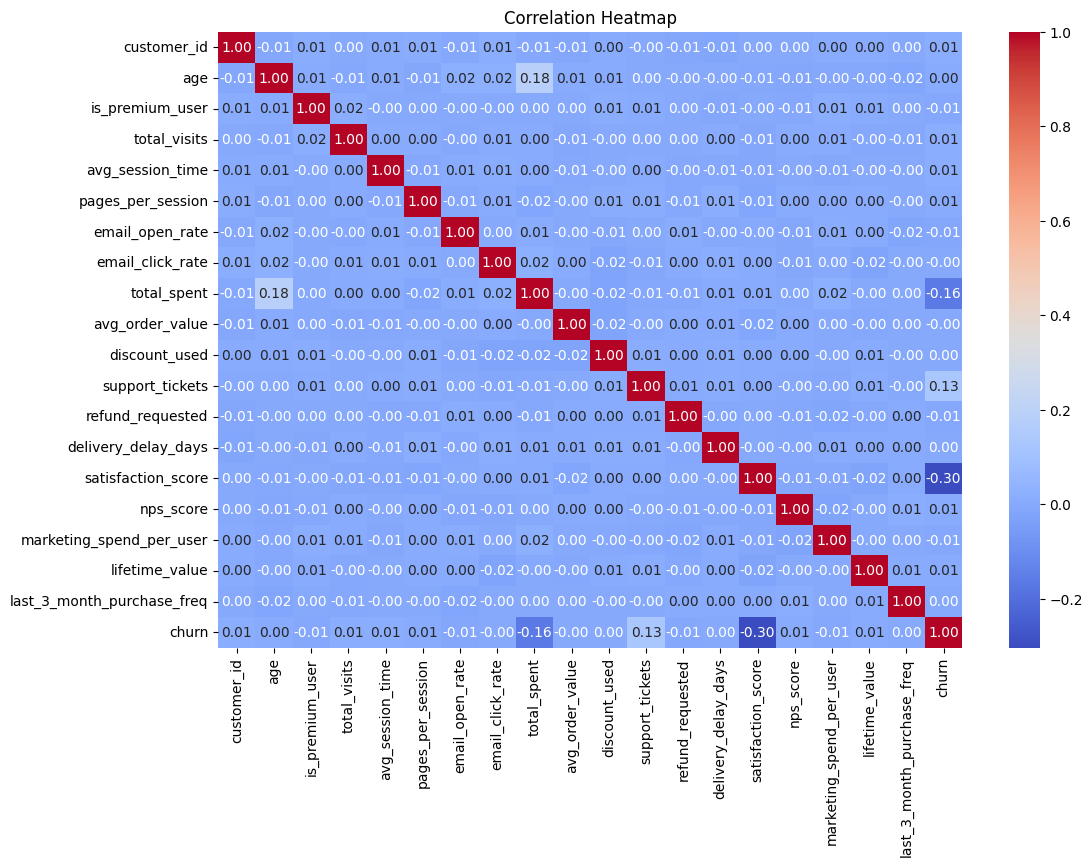

In [ ]:
# Menghitung korelasi
corr_matrix = df.corr(numeric_only=True)

# Membuat heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Menentukan fitur dan target
X = df_direct.drop('churn', axis=1)
y = df_direct['churn']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:


# =========================================================
# MODEL 1 - KONVENSIONAL
# Logistic Regression
# =========================================================

lr_model = LogisticRegression(max_iter=1000)

# =========================================================
# MODEL 2 - ENSEMBLE BAGGING
# Random Forest
# =========================================================

rf_model = RandomForestClassifier(random_state=42)

# =========================================================
# MODEL 3 - GABUNGAN MODEL KONVENSIONAL
# Voting Classifier
# =========================================================

voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', SVC(probability=True)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

# =========================================================
# MENYIMPAN SEMUA MODEL
# =========================================================

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Voting Classifier': voting_model
}

# =========================================================
# TRAINING DAN EVALUASI
# =========================================================

for name, model in models.items():

    print('=' * 60)
    print(f'Model : {name}')
    print('=' * 60)

    # Training
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Evaluasi
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Hasil evaluasi
    print(f'Accuracy  : {accuracy:.4f}')
    print(f'Precision : {precision:.4f}')
    print(f'Recall    : {recall:.4f}')
    print(f'F1-Score  : {f1:.4f}')

    # Confusion Matrix
    print('\nConfusion Matrix')
    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print('\nClassification Report')
    print(classification_report(y_test, y_pred))

Model : Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy  : 0.8477
Precision : 0.5111
Recall    : 0.1500
F1-Score  : 0.2319

Confusion Matrix
[[2474   66]
 [ 391   69]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.97      0.92      2540
           1       0.51      0.15      0.23       460

    accuracy                           0.85      3000
   macro avg       0.69      0.56      0.57      3000
weighted avg       0.81      0.85      0.81      3000

Model : Random Forest
Accuracy  : 0.8517
Precision : 0.5249
Recall    : 0.3435
F1-Score  : 0.4152

Confusion Matrix
[[2397  143]
 [ 302  158]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      2540
           1       0.52      0.34      0.42       460

    accuracy                           0.85      3000
   macro avg       0.71      0.64      0.67      3000
weighted avg       0.83      0.85      0.84      3000

Model : Voting Classifier


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy  : 0.8470
Precision : 0.6000
Recall    : 0.0065
F1-Score  : 0.0129

Confusion Matrix
[[2538    2]
 [ 457    3]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2540
           1       0.60      0.01      0.01       460

    accuracy                           0.85      3000
   macro avg       0.72      0.50      0.46      3000
weighted avg       0.81      0.85      0.78      3000

